In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec  #grid pels subplots
from matplotlib import colors         #colors
from matplotlib.colors import LogNorm   #normalitza a 0-1 en escala logarítmica 
from matplotlib import patches     #figures
from mpl_toolkits.mplot3d import Axes3D   #eixos en 3D
from mpl_toolkits.axes_grid1 import make_axes_locatable  #per canviar la posició dels eixos
from matplotlib.ticker import NullFormatter   #marques(tics) sense etiquetes en els eixos

from astroML.density_estimation import XDGMM
from astroML.plotting.tools import draw_ellipse
from astroML.crossmatch import crossmatch
from astroML.datasets import fetch_sdss_S82standards, fetch_imaging_sample
from astroML.stats import sigmaG
from astroML.utils.decorators import pickle_results
import os
import pickle

import astropy.table     #paquet per manejar taules de dades
from astropy.table import Table, Column, MaskedColumn   #importa taules, columnes i columnes que emmascaren dades invàlides
from astropy.visualization import astropy_mpl_style  #visualització 
from scipy.stats import gaussian_kde  #representation of a kernel-density estimate using Gaussian kernels.
import seaborn as sns  #llibreria per fer gràfics estadístics
import os.path   #per implementar diferents funcions amb pathnames ("dreceres")

from time import time   #mòdul de funcions de time access 
from sklearn import manifold, datasets #manifold: algoritme de dimensionality reduction 
                                       #sklearn (sci-kit learn): llibreria de Python per machine learning
import umap                #Uniform Manifold Approximation and Projection (UMAP) is a dimensionality reduction technique
from sklearn.decomposition import PCA  #Principal component analysis (PCA). Linear dimensionality reduction using Singular Value    
from sklearn.manifold import TSNE #t-SNE [1] is a tool to visualize high-dimensional data
from itertools import product   #producte cartesià

import obtain_data   #per importar dades d'altres fitxers

#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=16, usetex=True)

In [2]:
import importlib   #package per importar coses a python
importlib.reload(obtain_data)

galah_rc = obtain_data.galah_dr3_rc()   

galah_rc.get_ndimspace(feh=True, norm="stdev")

X = galah_rc.X            #(10941, 24)
Xerr = galah_rc.Xerr1         #(10941, 24)
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2    #(10941, 24, 24)

In [3]:
def gaussian(x, mu, sigma):
    return np.exp(-(x-mu)**2 / (2*sigma**2))

@pickle_results: using precomputed results from 'XD_1clusters.pkl'
@pickle_results: using precomputed results from 'XD_2clusters.pkl'
@pickle_results: using precomputed results from 'XD_3clusters.pkl'
@pickle_results: using precomputed results from 'XD_4clusters.pkl'
@pickle_results: using precomputed results from 'XD_5clusters.pkl'
@pickle_results: using precomputed results from 'XD_6clusters.pkl'
@pickle_results: using precomputed results from 'XD_7clusters.pkl'
@pickle_results: using precomputed results from 'XD_8clusters.pkl'
@pickle_results: using precomputed results from 'XD_9clusters.pkl'
@pickle_results: using precomputed results from 'XD_10clusters.pkl'


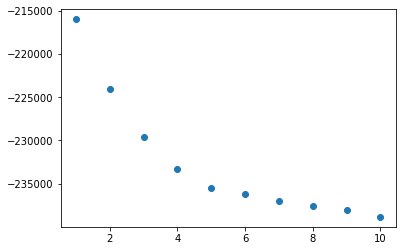

In [7]:
#arrays n_comp vs BIC
n_components_array = np.empty(shape=10)
BIC_array = np.empty(shape=10)

ck = ["k", "r", "gold", "g", "b",
          "orange", "cyan", "lime", "m", "yellow",
          "indianred", "hotpink", "peru", "cornflowerblue", "olivedrab",
          "grey", "turquoise", "lightpink", "navy", "khaki",
          "darkgreen", "crimson", "deepskyblue", "sandybrown", "limegreen",
          "deeppink", "dodgerblue", "rebeccapurple", "teal", "magenta"]

#Computing XDGMM
for n_components in range(1,11):
    @pickle_results('XD_'+str(n_components)+'clusters.pkl')
    def compute_XD(n_components=n_components, rseed=0, max_iter=100, verbose=True):
        np.random.seed(rseed)
        clf = XDGMM(n_components, max_iter=max_iter, tol=1E-5, verbose=verbose)
        clf.fit(X, Xcov) 
        return clf
    # Fit the model on training set
    clf = compute_XD(n_components)  # la primera vegada que es crida la funció ho guarda a l'arxiu pkl
    
    n_dim = 5   # representarem només 5 dimensions/elements
    np.random.seed(42) 
    
    #Calculate BIC
    logL = clf.logL(X,Xcov)  # logaritme de la likelihood
    k = n_components * ( 1 + n_dim + (n_dim*(n_dim+1)/2) )  # nº de free model parameters
    N = 10941       # nº d'estrelles
    BIC = (k*np.log(N)) -(2*logL/np.log(10)) 
    #index = int((n_components/5)-1)
    index = n_components - 1
    
    n_components_array[index] = n_components
    BIC_array[index] = BIC
    
plt.scatter(n_components_array, BIC_array)